# Retail Demand Forecasting and Sales Analytics for Walmart Using Time Series and Machine Learning

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

In [3]:
train=pd.read_csv("train[1].csv")
train

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False
...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False
421566,45,98,2012-10-05,628.10,False
421567,45,98,2012-10-12,1061.02,False
421568,45,98,2012-10-19,760.01,False


In [4]:
features=pd.read_csv("features[1].csv")
features

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False
...,...,...,...,...,...,...,...,...,...,...,...,...
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False


In [5]:
stores=pd.read_csv("stores[1].csv")
stores

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875
5,6,A,202505
6,7,B,70713
7,8,A,155078
8,9,B,125833
9,10,B,126512


In [6]:
df=pd.merge(train,features,
            on=["Store","Date","IsHoliday"],
            how="left")
df=pd.merge(df,stores,
            on="Store",
            how="left")
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,False,64.88,3.997,4556.61,20.64,1.50,1601.01,3288.25,192.013558,8.684,B,118221
421566,45,98,2012-10-05,628.10,False,64.89,3.985,5046.74,NaN,18.82,2253.43,2340.01,192.170412,8.667,B,118221
421567,45,98,2012-10-12,1061.02,False,54.47,4.000,1956.28,NaN,7.89,599.32,3990.54,192.327265,8.667,B,118221
421568,45,98,2012-10-19,760.01,False,56.47,3.969,2004.02,NaN,3.18,437.73,1537.49,192.330854,8.667,B,118221


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [8]:
df.isnull().sum()

Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

In [9]:
df["Date"]=pd.to_datetime(df["Date"])

In [10]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week
df["Quarter"]=df["Date"].dt.quarter

<Axes: xlabel='Date'>

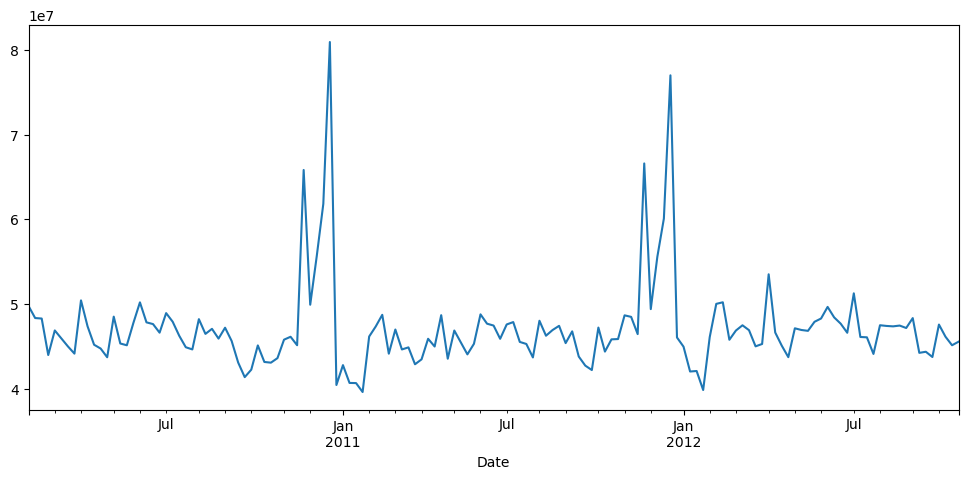

In [11]:
monthly_sales=(df.groupby("Date")["Weekly_Sales"].sum()
              )
monthly_sales.plot(figsize=(12,5))

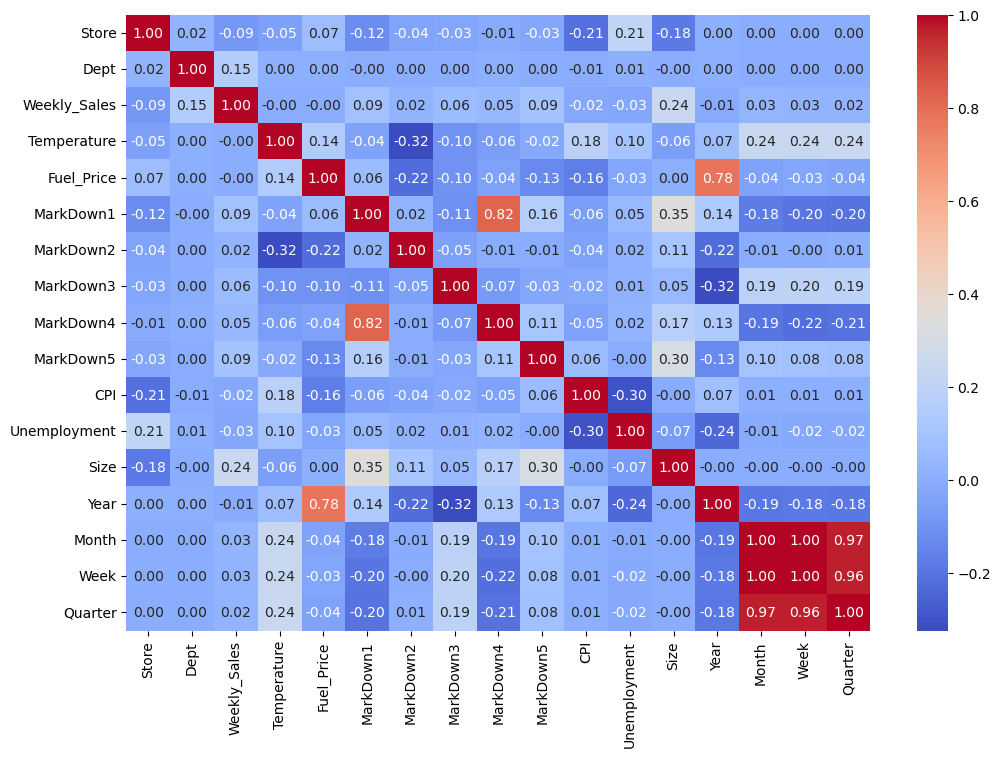

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [13]:
le = LabelEncoder()

df['Type'] = le.fit_transform(df['Type'])

In [14]:
df['Type'].unique()

array([0, 1, 2])

In [15]:
sales = df.groupby('Date')['Weekly_Sales'].sum()

In [16]:
top_store = df.groupby('Store')['Weekly_Sales'].sum()

top_store.sort_values(ascending=False).head(10)

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64

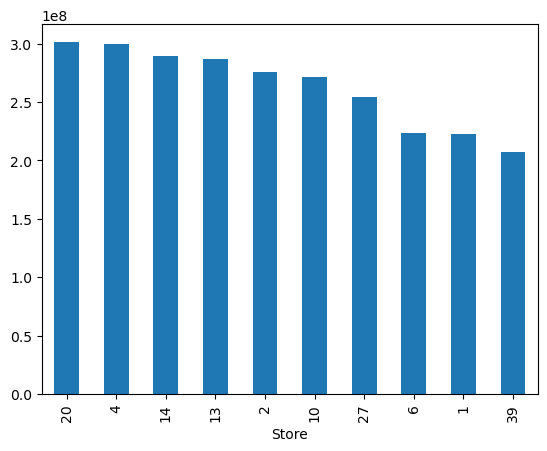

In [17]:
top_store.sort_values(
ascending=False).head(10).plot(kind='bar')

plt.show()

In [18]:
holiday_sales = df.groupby(
'IsHoliday')['Weekly_Sales'].mean()

print(holiday_sales)

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64


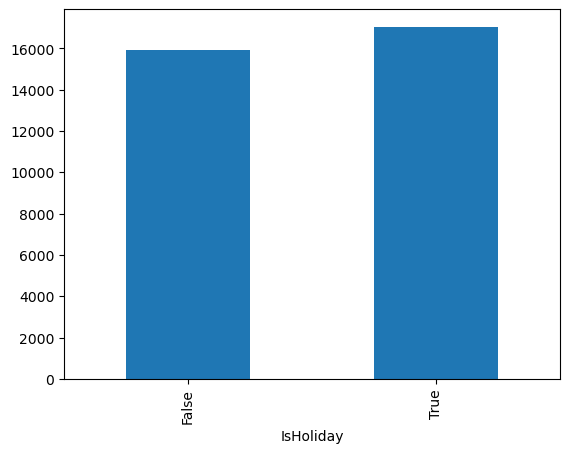

In [19]:
holiday_sales.plot(kind='bar')

plt.show()

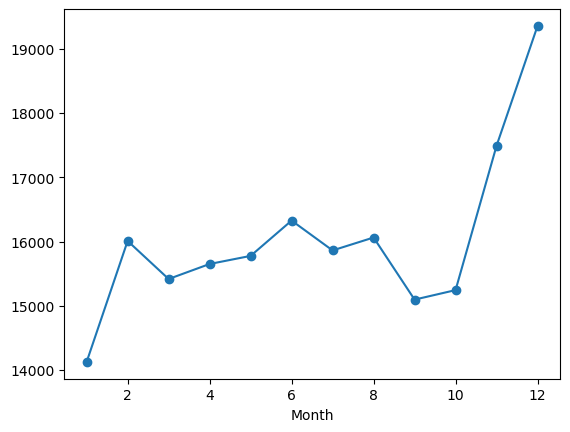

In [20]:
monthly_sales = df.groupby(
'Month')['Weekly_Sales'].mean()

monthly_sales.plot(marker='o')

plt.show()

In [21]:
ts = df.groupby('Date')['Weekly_Sales'].sum()
ts.head()

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Name: Weekly_Sales, dtype: float64

In [22]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [23]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic:",result[0])

print("p-value:",result[1])

ADF Statistic: -5.908297957186332
p-value: 2.675979158986058e-07


The stationarity of the weekly sales series was assessed using the Augmented Dickey-Fuller (ADF) test. The test produced an ADF statistic of -5.908 and a p-value of 2.68 × 10⁻⁷, which is significantly below the 0.05 significance level. Therefore, the null hypothesis of a unit root was rejected, indicating that the series is stationary. Consequently, no differencing was required and the differencing order was set to d = 0 in the ARIMA/SARIMA models.

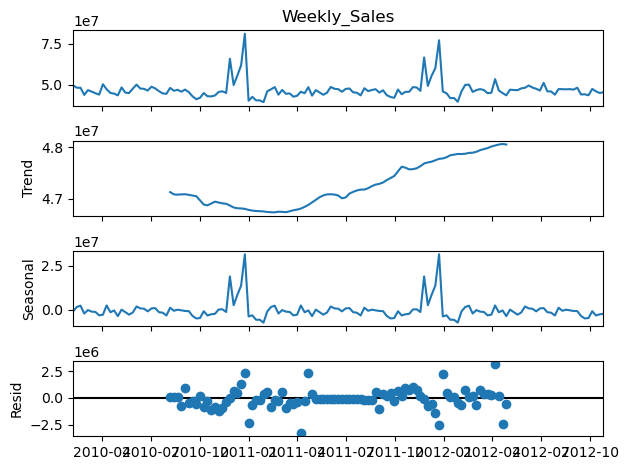

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

decomposition = seasonal_decompose(
    ts,
    model='additive',
    period=52  # weekly data with yearly seasonality
)

decomposition.plot()
plt.show()

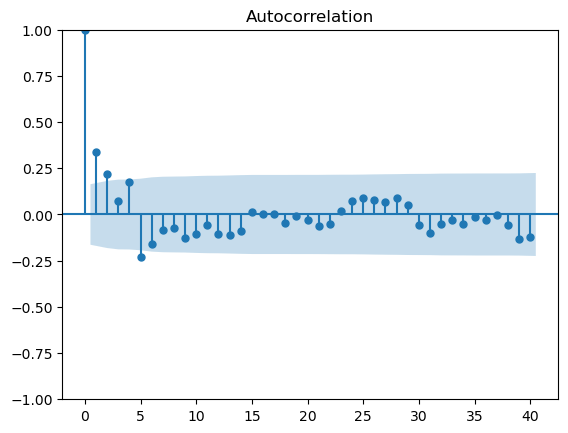

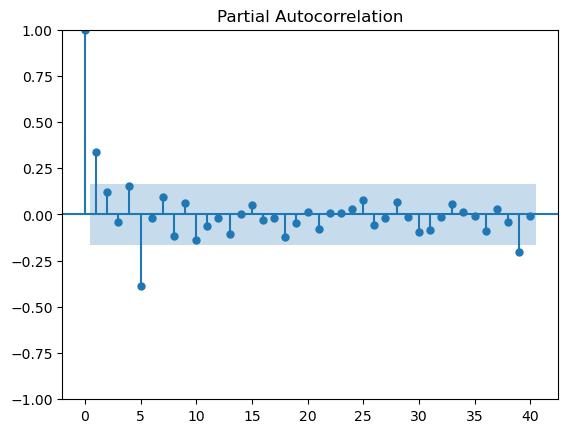

In [25]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts, lags=40)
plt.show()

plot_pacf(ts, lags=40)
plt.show()

In [26]:
print(type(ts))
print(ts.dtype)

<class 'pandas.core.series.Series'>
float64


In [27]:
train_size = int(len(ts)*0.8)

train_ts = ts[:train_size]
test_ts = ts[train_size:]

# Arima

In [28]:
from statsmodels.tsa.arima.model import ARIMA

orders = [
    (1,0,1),
    (2,0,1),
    (5,0,1),
    (5,0,2)
]

for order in orders:

    model = ARIMA(
        train_ts,
        order=order
    )

    result = model.fit()

    print(order, result.aic)

C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


(1, 0, 1) 3875.041223682486


C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


(2, 0, 1) 3872.822956830665


C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


(5, 0, 1) 3861.6626353583624


C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


(5, 0, 2) 3862.977689926334


In [29]:
best_model = ARIMA(
    train_ts,
    order=(5,0,1)
)

best_fit = best_model.fit()

C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [30]:
forecast = best_fit.forecast(
    steps=len(test_ts)
)

In [31]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

a_mae = mean_absolute_error(
    test_ts,
    forecast
)

a_rmse = np.sqrt(
    mean_squared_error(
        test_ts,
        forecast
    )
)

print("MAE =",a_mae)
print("RMSE =",a_rmse)

MAE = 1674988.5559049158
RMSE = 2124017.289608609


In [32]:
a_mape = np.mean(
    np.abs(
        (test_ts-forecast)/test_ts
    )
)*100

print("MAPE =",a_mape)

MAPE = 3.623813056906924


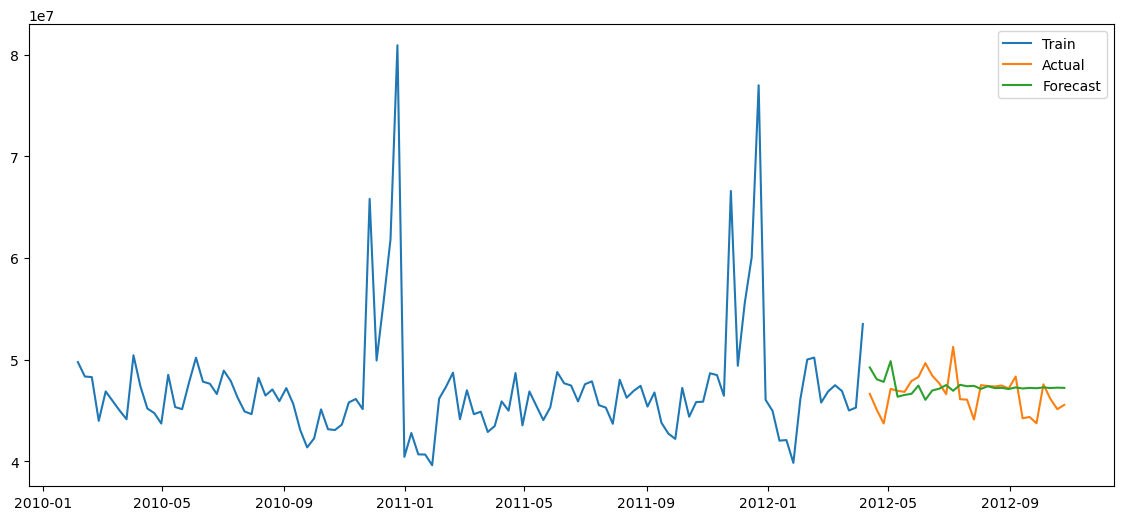

In [33]:
plt.figure(figsize=(14,6))

plt.plot(
    train_ts,
    label='Train'
)

plt.plot(
    test_ts,
    label='Actual'
)

plt.plot(
    test_ts.index,
    forecast,
    label='Forecast'
)

plt.legend()

plt.show()

# Residuals

In [34]:
residuals = best_fit.resid

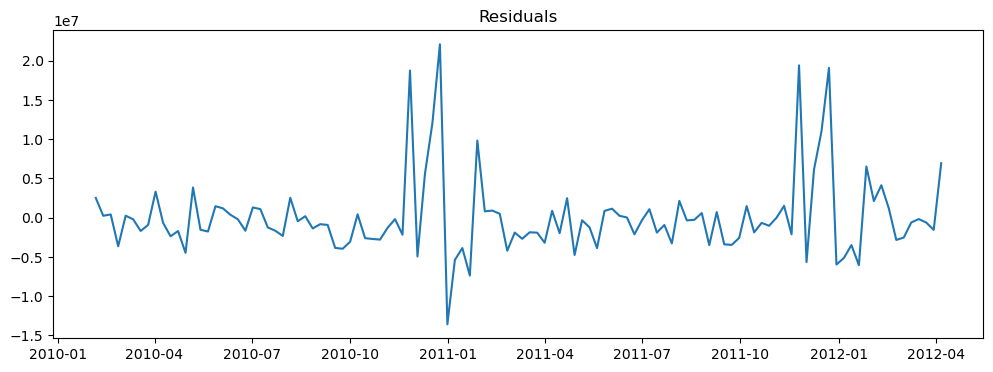

In [35]:
plt.figure(figsize=(12,4))
plt.plot(residuals)
plt.title("Residuals")
plt.show()

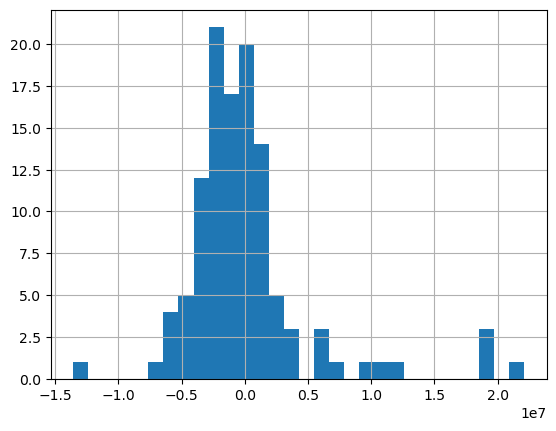

In [36]:
residuals.hist(bins=30)
plt.show()

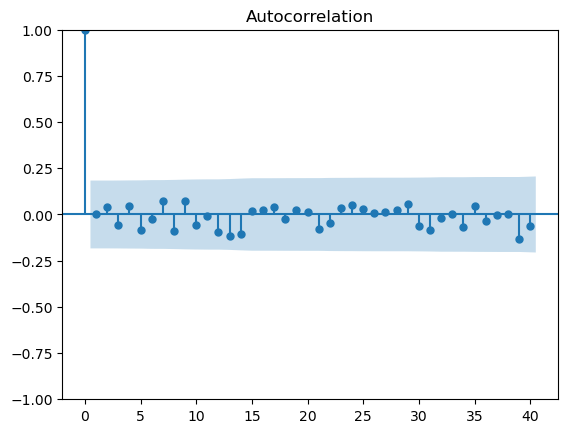

In [37]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    residuals,
    lags=40
)

plt.show()

In [38]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    residuals,
    lags=[10],
    return_df=True
)

print(lb)

     lb_stat  lb_pvalue
10  4.497371   0.922134


In [39]:
final_model = ARIMA(
    ts,
    order=(5,0,1)
)

final_fit = final_model.fit()

C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [40]:
future = final_fit.forecast(
    steps=12
)

print(future)

2012-11-02    4.783513e+07
2012-11-09    4.693971e+07
2012-11-16    4.700025e+07
2012-11-23    4.735526e+07
2012-11-30    4.799828e+07
2012-12-07    4.716312e+07
2012-12-14    4.721875e+07
2012-12-21    4.722714e+07
2012-12-28    4.731069e+07
2013-01-04    4.687235e+07
2013-01-11    4.703672e+07
2013-01-18    4.704855e+07
Freq: W-FRI, Name: predicted_mean, dtype: float64


In [41]:
future_dates = pd.date_range(
    start=ts.index[-1],
    periods=13,
    freq='W'
)[1:]

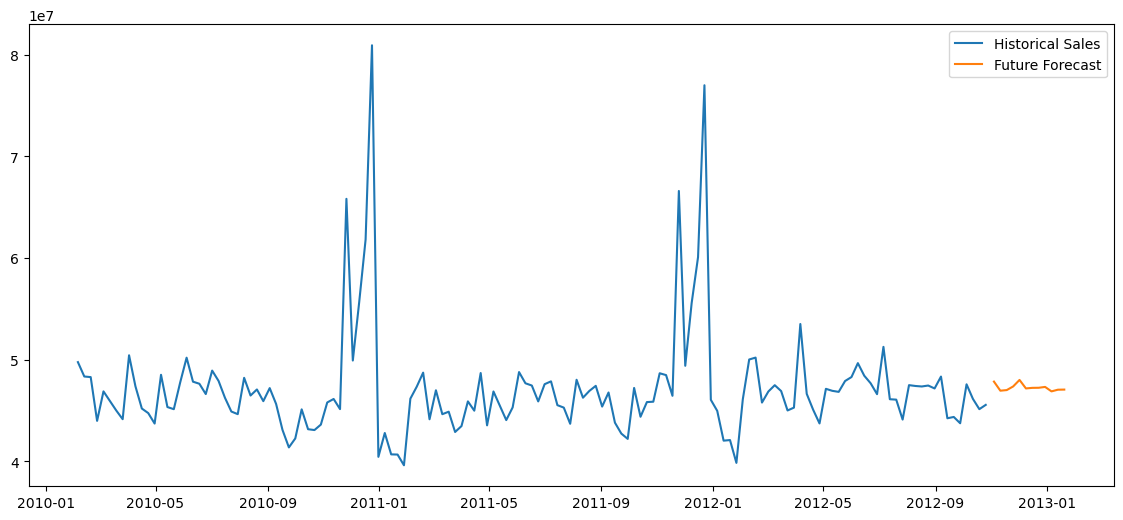

In [42]:
plt.figure(figsize=(14,6))

plt.plot(
    ts,
    label='Historical Sales'
)

plt.plot(
    future_dates,
    future,
    label='Future Forecast'
)

plt.legend()

plt.show()

# sarima
## 52 weeks = yearly seasonality

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [44]:
sarima = SARIMAX(
    train_ts,
    order=(5,0,1),
    seasonal_order=(1,0,1,52)
)

sarima_fit = sarima.fit()
print(sarima_fit.summary())

C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
C:\Users\shiva\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  114
Model:             SARIMAX(5, 0, 1)x(1, 0, 1, 52)   Log Likelihood               -1919.756
Date:                            Mon, 06 Jul 2026   AIC                           3857.512
Time:                                    16:59:58   BIC                           3882.138
Sample:                                02-05-2010   HQIC                          3867.506
                                     - 04-06-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2918      1.313      0.222      0.824      -2.282       2.865
ar.L2          0.3309      0.647   

In [45]:
sarima_forecast = sarima_fit.forecast(
    steps=len(test_ts)
)

In [46]:
s_mae = mean_absolute_error(
    test_ts,
    sarima_forecast
)

s_rmse = np.sqrt(
    mean_squared_error(
        test_ts,
        sarima_forecast
    )
)

s_mape = np.mean(
    np.abs(
        (test_ts-sarima_forecast)
        /test_ts
    )
)*100

print("MAE :",s_mae)
print("RMSE :",s_rmse)
print("MAPE :",s_mape)

MAE : 1499302.022153838
RMSE : 2075219.3144873208
MAPE : 3.2279593638065913


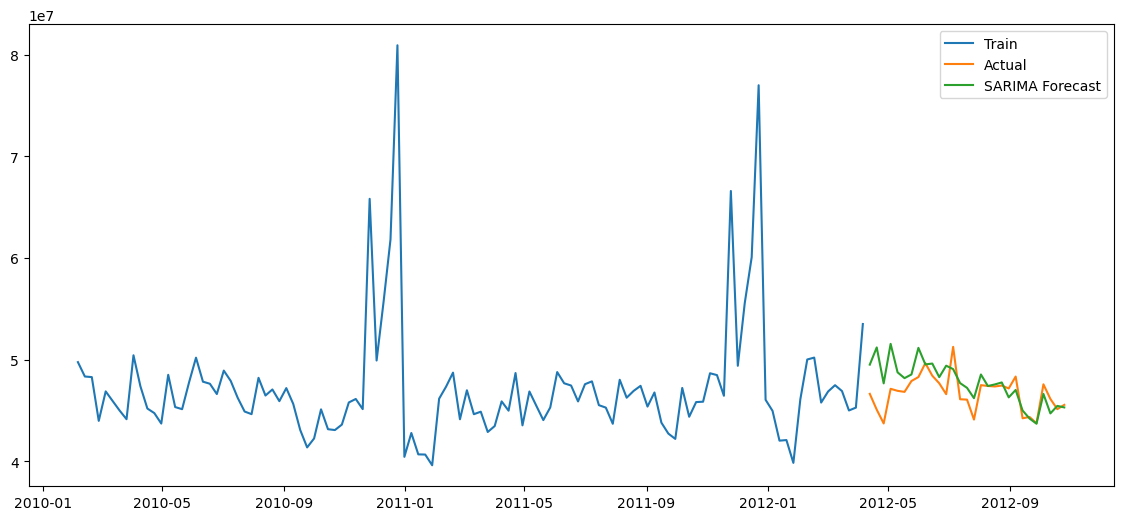

In [47]:
plt.figure(figsize=(14,6))

plt.plot(
    train_ts,
    label='Train'
)

plt.plot(
    test_ts,
    label='Actual'
)

plt.plot(
    test_ts.index,
    sarima_forecast,
    label='SARIMA Forecast'
)

plt.legend()

plt.show()

# xgboost

In [48]:
train = pd.read_csv('train[1].csv')

features = pd.read_csv('features[1].csv')

stores = pd.read_csv('stores[1].csv')

In [49]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [50]:
from xgboost import XGBRegressor

In [51]:
df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values(
    ["Store", "Dept", "Date"]
)

In [52]:
markdown_cols = [
    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5"
]

df[markdown_cols] = (
    df[markdown_cols]
    .fillna(0)
)

In [53]:
df["Year"] = df["Date"].dt.year

df["Month"] = df["Date"].dt.month

df["Quarter"] = df["Date"].dt.quarter

df["Week"] = (
    df["Date"]
    .dt.isocalendar()
    .week
    .astype(int)
)

In [54]:
df["lag_1"] = (
    df.groupby(
        ["Store", "Dept"]
    )["Weekly_Sales"]
    .shift(1)
)

df["lag_2"] = (
    df.groupby(
        ["Store", "Dept"]
    )["Weekly_Sales"]
    .shift(2)
)

df["lag_4"] = (
    df.groupby(
        ["Store", "Dept"]
    )["Weekly_Sales"]
    .shift(4)
)

df["lag_52"] = (
    df.groupby(
        ["Store", "Dept"]
    )["Weekly_Sales"]
    .shift(52)
)

In [55]:
df["rolling_4"] = (
    df.groupby(
        ["Store", "Dept"]
    )["Weekly_Sales"]
    .transform(
        lambda x: x.shift(1)
                  .rolling(4)
                  .mean()
    )
)

df["rolling_12"] = (
    df.groupby(
        ["Store", "Dept"]
    )["Weekly_Sales"]
    .transform(
        lambda x: x.shift(1)
                  .rolling(12)
                  .mean()
    )
)

In [56]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["Type"] = le.fit_transform(
    df["Type"]
)


In [57]:
df = df.dropna()

In [58]:
split_date = "2012-06-01"

train_df = (
    df[df["Date"] < split_date]
)

test_df = (
    df[df["Date"] >= split_date]
)

In [59]:
feature_cols = [

    "Store",
    "Dept",

    "IsHoliday",

    "Temperature",
    "Fuel_Price",

    "CPI",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",

    "Type",
    "Size",

    "Year",
    "Month",
    "Quarter",
    "Week",

    "lag_1",
    "lag_2",
    "lag_4",
    "lag_52",

    "rolling_4",
    "rolling_12"
]

In [60]:
X_train = train_df[feature_cols]

y_train = train_df["Weekly_Sales"]

X_test = test_df[feature_cols]

y_test = test_df["Weekly_Sales"]

In [61]:
from xgboost import XGBRegressor

model = XGBRegressor(

    n_estimators=500,

    learning_rate=0.05,

    max_depth=8,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42
)

model.fit(
    X_train,
    y_train
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [62]:
pred = model.predict(
    X_test
)

In [64]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

xg_mae = mean_absolute_error(
    y_test,
    pred
)

xg_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred
    )
)

print("MAE :",xg_mae)
print("RMSE:", xg_rmse)

MAE : 1275.6484099953643
RMSE: 2676.7704356863087


In [66]:
xg_wmape = (
    np.abs(y_test - pred).sum()
    /
    np.abs(y_test).sum()
) * 100

print("WMAPE:", xg_wmape)

WMAPE: 7.912863583427004


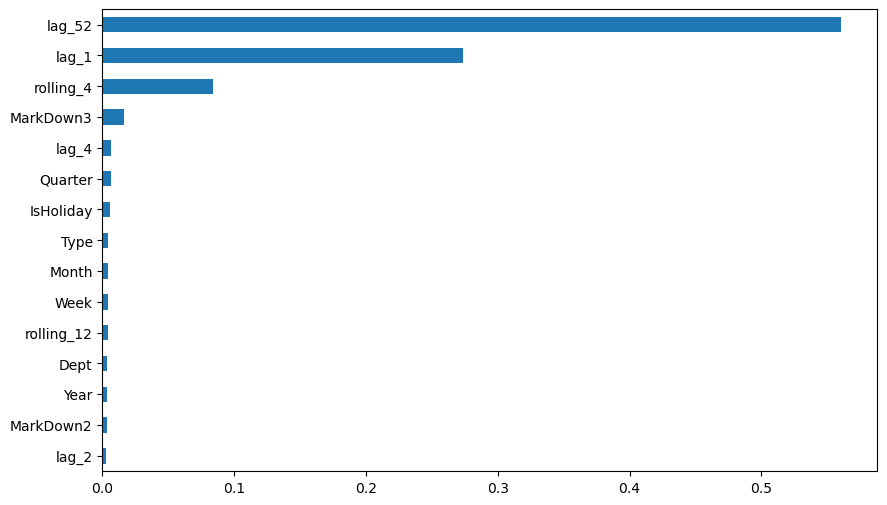

In [67]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=feature_cols
)

importance.sort_values().tail(15).plot(
    kind="barh",
    figsize=(10,6)
)

plt.show()

# Comparison

In [68]:
comparison = pd.DataFrame({

'Model':['ARIMA',
         'SARIMA',
         'XGBoost'],

'MAE':[a_mae,
       s_mae,
       xg_mae],

'RMSE':[a_rmse,
        s_rmse,
        xg_rmse],

'MAPE':[a_mape,
        s_mape,
        xg_wmape]
})

print(comparison)

     Model           MAE          RMSE      MAPE
0    ARIMA  1.674989e+06  2.124017e+06  3.623813
1   SARIMA  1.499302e+06  2.075219e+06  3.227959
2  XGBoost  1.275648e+03  2.676770e+03  7.912864


In [69]:
print(pred[:10])
print(y_test[:10])

[17006.95  17067.184 17050.107 17553.486 16380.8   16415.549 17662.914
 17023.625 16705.842 16842.357]
121    16065.49
122    17666.00
123    17558.82
124    16633.41
125    15722.82
126    17823.37
127    16566.18
128    16348.06
129    15731.18
130    16628.31
Name: Weekly_Sales, dtype: float64


This project developed an end-to-end retail demand forecasting framework using Walmart's historical sales data. Through exploratory analysis, it was observed that weekly sales are influenced by seasonal trends, holiday periods, markdown promotions, and store-specific characteristics. Statistical testing confirmed that the sales series was stationary, enabling effective application of time-series forecasting models.

Among the statistical models, SARIMA outperformed ARIMA, demonstrating the importance of capturing seasonal patterns in retail demand. To further incorporate business drivers such as holidays, markdowns, store size, economic indicators, and historical sales behavior, an XGBoost model with engineered lag and rolling features was developed. The machine learning approach achieved the best forecasting performance, indicating that retail sales are driven by both temporal patterns and external business factors.

In [70]:
pip install shap


Note: you may need to restart the kernel to use updated packages.


In [ ]:
import shap

In [ ]:
import shap
import matplotlib.pyplot as plt

# Create explainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

# Bar plot
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

# Waterfall plot for one prediction
sample = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[sample],
        base_values=explainer.expected_value,
        data=X_test.iloc[sample],
        feature_names=X_test.columns
    )
)

SHAP analysis revealed that historical sales patterns (lag_52 and rolling_12) were the strongest predictors of weekly demand. Business-related features such as holiday indicators and promotional markdowns also had a significant positive impact on sales forecasts. This demonstrates that both historical trends and business events influence retail demand, making the model both accurate and interpretable.